# Dataset Demo - EW4Energy Rain over Africa

* data duration 6 months april to sep 2025
* spatial location: 40S to 40N, 20W to 55 E
* data location `RoA/2025-08-01`
* file format `ROA-2025-08-01T00:00:00.nc`
* data file  every 15 minutes 
* variables
  * probability of precip
  * posterior mean

Data set info
https://rainoverafrica.ai/

In [1]:
import pathlib
import os
import datetime

In [2]:
import xarray

In [ ]:
xarray.open_dataset('/gws/nopw/j04/ew4energy/TOOCAN-AFRICA-20240801-20240831.nc')

In [3]:
ew4_base_dir = pathlib.Path('/gws/nopw/j04/ew4energy')
print(ew4_base_dir.is_dir())
ew4_base_dir

True


PosixPath('/gws/nopw/j04/ew4energy')

In [4]:
roa_dir = ew4_base_dir / 'RoA' 

In [5]:
file_path = roa_dir / '2025-08-01' / 'ROA-2025-08-01T00:00:00.nc'

In [6]:
ds1 = xarray.open_dataset(file_path)

In [7]:
ds1.assign_coords({'time': ds1.attrs['start_time']})

<xarray.Dataset> Size: 197MB
Dimensions:             (latitude: 2962, longitude: 2777)
Coordinates:
  * latitude            (latitude) float64 24kB -40.0 -39.97 ... 39.97 40.0
  * longitude           (longitude) float64 22kB -20.0 -19.97 ... 54.97 55.0
    time                <U16 64B '2025-08-01T00:00'
Data variables:
    posterior_mean      (latitude, longitude) float64 66MB ...
    probability_precip  (latitude, longitude) float64 66MB ...
    acq_time            (latitude, longitude) datetime64[ns] 66MB ...
Attributes:
    CDI:             Climate Data Interface version 2.5.0 (https://mpimet.mpg...
    Conventions:     CF-1.6
    msg_filename:    MSG320250801-S0000-E0015.nc
    start_time:      2025-08-01T00:00
    end_time:        2025-08-01T00:15
    sat_actual_lon:  0.3273348685502501
    sat_actual_lat:  -3.6463632474268954
    sat_actual_alt:  35790715.904694475
    creator:         rainoverafrica.ai
    history:         Fri Aug 01 23:55:02 2025: cdo -f nc4 -z zip_1 copy /home...
    CDO:             Climate Data Operators version 2.5.0 (https://mpimet.mpg...

In [8]:
ds1

<xarray.Dataset> Size: 197MB
Dimensions:             (latitude: 2962, longitude: 2777)
Coordinates:
  * latitude            (latitude) float64 24kB -40.0 -39.97 ... 39.97 40.0
  * longitude           (longitude) float64 22kB -20.0 -19.97 ... 54.97 55.0
Data variables:
    posterior_mean      (latitude, longitude) float64 66MB ...
    probability_precip  (latitude, longitude) float64 66MB ...
    acq_time            (latitude, longitude) datetime64[ns] 66MB ...
Attributes:
    CDI:             Climate Data Interface version 2.5.0 (https://mpimet.mpg...
    Conventions:     CF-1.6
    msg_filename:    MSG320250801-S0000-E0015.nc
    start_time:      2025-08-01T00:00
    end_time:        2025-08-01T00:15
    sat_actual_lon:  0.3273348685502501
    sat_actual_lat:  -3.6463632474268954
    sat_actual_alt:  35790715.904694475
    creator:         rainoverafrica.ai
    history:         Fri Aug 01 23:55:02 2025: cdo -f nc4 -z zip_1 copy /home...
    CDO:             Climate Data Operators version 2.5.0 (https://mpimet.mpg...

In [9]:
min(ds1['latitude']), max(ds1['latitude'])

(<xarray.DataArray 'latitude' ()> Size: 8B
 array(-40.)
 Coordinates:
     latitude  float64 8B -40.0
 Attributes:
     axis:     Y,
 <xarray.DataArray 'latitude' ()> Size: 8B
 array(40.)
 Coordinates:
     latitude  float64 8B 40.0
 Attributes:
     axis:     Y)

In [10]:
min(ds1['longitude']), max(ds1['longitude'])

(<xarray.DataArray 'longitude' ()> Size: 8B
 array(-20.)
 Coordinates:
     longitude  float64 8B -20.0
 Attributes:
     axis:     X,
 <xarray.DataArray 'longitude' ()> Size: 8B
 array(55.)
 Coordinates:
     longitude  float64 8B 55.0
 Attributes:
     axis:     X)

In [11]:
list(ds1.variables)

['posterior_mean', 'probability_precip', 'acq_time', 'longitude', 'latitude']

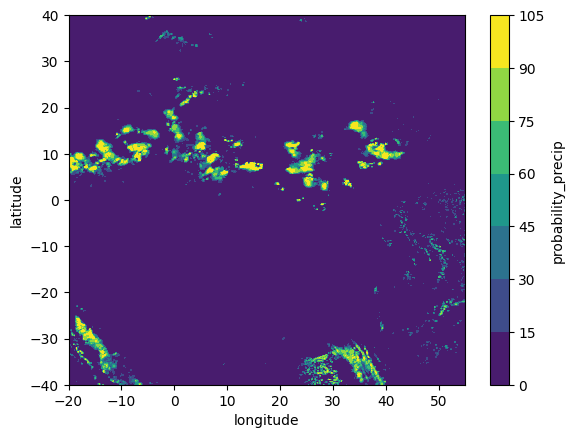

In [12]:
ds1['probability_precip'].plot.contourf()

In [13]:
(datetime.datetime.now() - datetime.datetime.now()).seconds // 60

1439

In [14]:
(datetime.datetime(2023,3,11,0,0)-  datetime.datetime(2023,3,1,0,0)) /  datetime.timedelta(minutes=15)

960.0

In [15]:
def get_roa_data(roa_dir, start_dt, end_dt):
    file_time_delta = datetime.timedelta(minutes=15)
    num_steps = int((end_dt - start_dt) / file_time_delta)
    dir_template = '{dt.year:04d}-{dt.month:02d}-{dt.day:02d}'
    fname_template = 'ROA-{dt.year:04d}-{dt.month:02d}-{dt.day:02d}T{dt.hour:02d}:{dt.minute:02d}:{dt.second:02d}.nc'
    path_list = {}
    for dt_ix in range(num_steps):#
        select_time = start_dt + (dt_ix * file_time_delta)
        select_path = roa_dir / dir_template.format(dt=select_time) / fname_template.format(dt=select_time)
        if not select_path.is_file():
            raise FileNotFoundError(select_path)
        path_list[select_time] = select_path
    print(f'num files found {len(path_list)}')
    return path_list
        
    
    
    

In [16]:
path_list = get_roa_data(roa_dir,
             datetime.datetime(2025,6,1,0,0),
             datetime.datetime(2025,6,1,3,0),
            )

num files found 12


In [17]:

ds_list1 = {dt: xarray.open_dataset(p1) for dt, p1 in path_list.items()}

for select_dt, select_ds in ds_list1.items():
     select_ds.assign_coords({'time': select_dt})
 

In [18]:
ds_list1

{datetime.datetime(2025, 6, 1, 0, 0): <xarray.Dataset> Size: 197MB
 Dimensions:             (latitude: 2962, longitude: 2777)
 Coordinates:
   * latitude            (latitude) float64 24kB -40.0 -39.97 ... 39.97 40.0
   * longitude           (longitude) float64 22kB -20.0 -19.97 ... 54.97 55.0
 Data variables:
     posterior_mean      (latitude, longitude) float64 66MB ...
     probability_precip  (latitude, longitude) float64 66MB ...
     acq_time            (latitude, longitude) datetime64[ns] 66MB ...
 Attributes:
     CDI:             Climate Data Interface version 2.5.0 (https://mpimet.mpg...
     Conventions:     CF-1.6
     msg_filename:    MSG320250601-S0000-E0015.nc
     start_time:      2025-06-01T00:00
     end_time:        2025-06-01T00:15
     sat_actual_lon:  0.019739285081722603
     sat_actual_lat:  -0.52702446272524
     sat_actual_alt:  35788291.55128112
     creator:         rainoverafrica.ai
     history:         Sat Jul 19 19:33:36 2025: cdo -f nc4 -z zip_1 copy /

In [19]:
# todo
# add time coordinate to each file as it is loaded
# join together into a dataset based on time

In [20]:
xarray.open_mfdataset()

TypeError: open_mfdataset() missing 1 required positional argument: 'paths'